In [19]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(" All imports successful!")
print(f"TensorFlow version: {tf.__version__}")

 All imports successful!
TensorFlow version: 2.20.0


In [20]:
df = pd.read_csv('../data/processed/all_stocks_featured.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

print(f"Data loaded: {df.shape}")
print(f"Stocks: {df['Symbol'].nunique()}")

Data loaded: (117464, 37)
Stocks: 49


In [21]:
SYMBOL          = 'HDFCBANK'
SEQUENCE_LENGTH = 30

# Filter stock
stock_df = df[df['Symbol'] == SYMBOL].copy()
stock_df = stock_df.sort_values('Date').reset_index(drop=True)
stock_df = stock_df[stock_df['Date'] >= '2012-01-01'].reset_index(drop=True)

print(f"Total records for {SYMBOL}: {len(stock_df)}")

# Use only Close price
close_prices = stock_df['Close'].values.reshape(-1, 1)

# Scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_prices)

# Create sequences
X, y = [], []
for i in range(SEQUENCE_LENGTH, len(scaled)):
    X.append(scaled[i-SEQUENCE_LENGTH:i, 0])
    y.append(scaled[i, 0])

X = np.array(X).reshape(-1, SEQUENCE_LENGTH, 1)
y = np.array(y)

# 80/20 split
split   = int(len(X) * 0.80)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

Total records for HDFCBANK: 2311
Train shape: (1824, 30, 1)
Test shape:  (457, 30, 1)


In [22]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(50, return_sequences=True,
         input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()
print("✅ Model built successfully!")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model built successfully!


In [23]:
tf.random.set_seed(42)
np.random.seed(42)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print(" Training LSTM model...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

print(f"\n Training complete!")
print(f"Total epochs: {len(history.history['loss'])}")
print(f"Best epoch:   {np.argmin(history.history['val_loss']) + 1}")

 Training LSTM model...
Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0034 - val_loss: 0.0020
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0126 - val_loss: 0.0074
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0117 - val_loss: 0.0023
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0056 - val_loss: 0.0022
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0023 - val_loss: 0.0031
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0013 - val_loss: 0.0041
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0012 - val_loss: 0.0041
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0013 - val_loss: 0.0044
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0010 - val_loss: 0.0039
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 

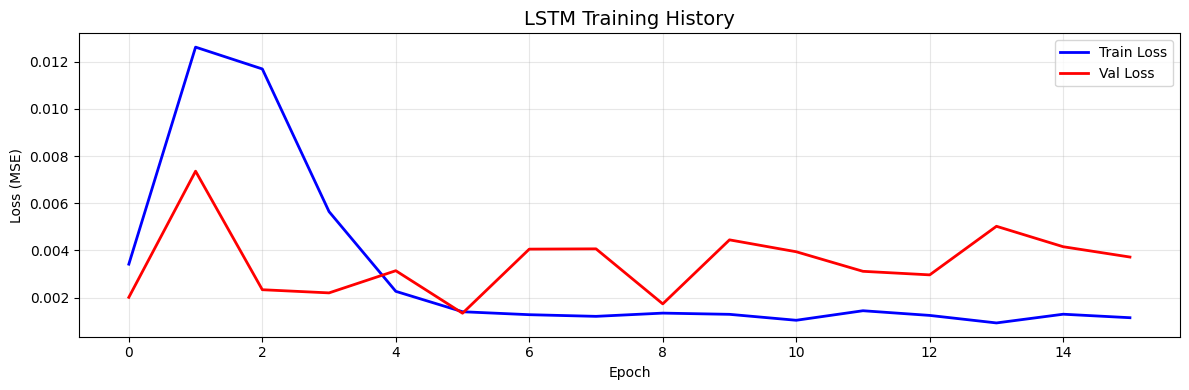

  Training history saved!


In [24]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'],
         label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'],
         label='Val Loss',   color='red',  linewidth=2)
plt.title('LSTM Training History', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/lstm_training_history.png', dpi=150)
plt.show()
print("  Training history saved!")

In [25]:
# Predictions
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform
y_pred_actual = scaler.inverse_transform(
    y_pred_scaled).flatten()
y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)).flatten()

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
r2   = r2_score(y_test_actual, y_pred_actual)

actual_dir    = np.diff(y_test_actual) > 0
predicted_dir = np.diff(y_pred_actual) > 0
dir_acc       = np.mean(actual_dir == predicted_dir) * 100

print("=" * 45)
print("     LSTM MODEL — EVALUATION RESULTS")
print("=" * 45)
print(f"  Stock               : {SYMBOL}")
print(f"  RMSE                : {rmse:.2f} INR")
print(f"  MAE                 : {mae:.2f} INR")
print(f"  R² Score            : {r2:.4f}")
print(f"  Directional Accuracy: {dir_acc:.2f}%")
print("=" * 45)

lstm_metrics = {
    'rmse': rmse, 'mae': mae,
    'r2': r2, 'dir_acc': dir_acc
}

     LSTM MODEL — EVALUATION RESULTS
  Stock               : HDFCBANK
  RMSE                : 202.25 INR
  MAE                 : 159.43 INR
  R² Score            : 0.7418
  Directional Accuracy: 51.54%


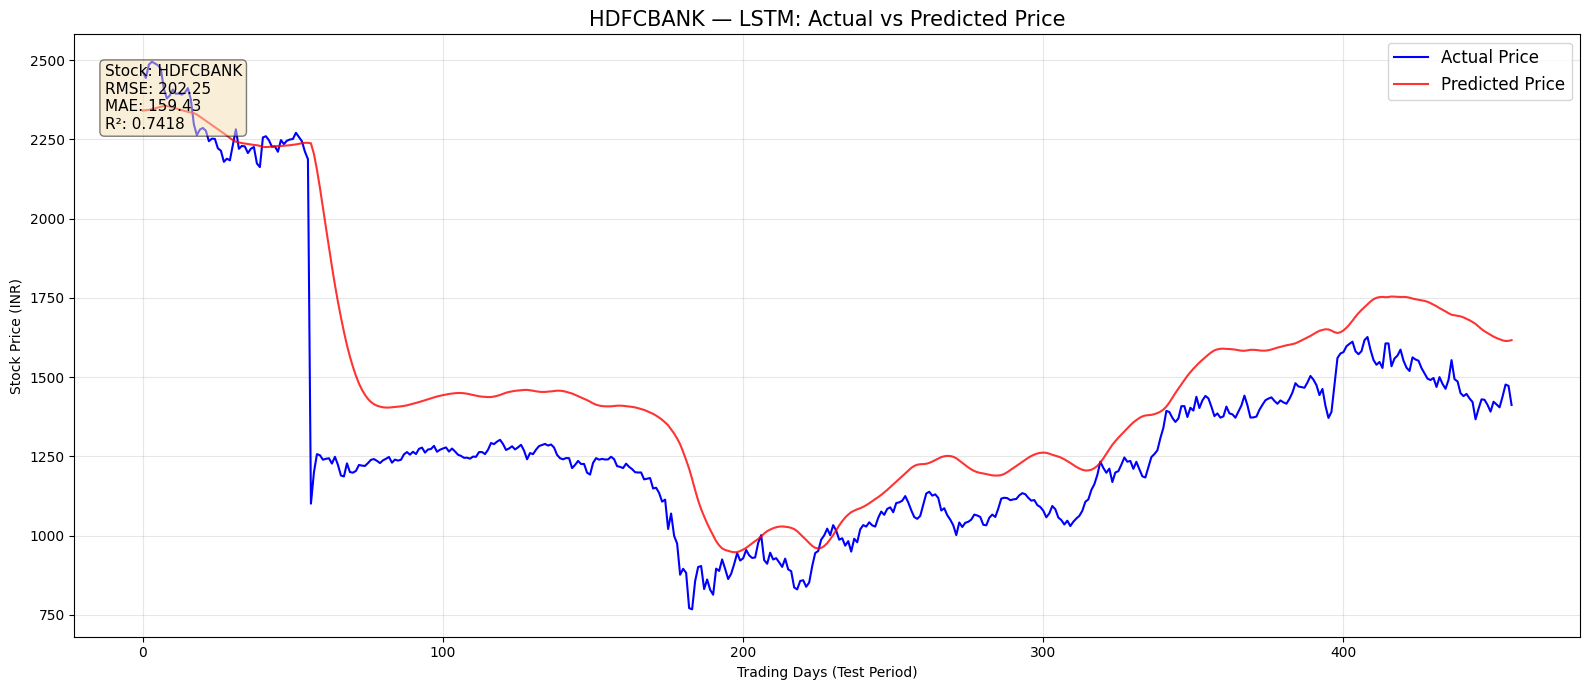

Actual range:    ₹768 — ₹2495
Predicted range: ₹948 — ₹2355


In [26]:
plt.figure(figsize=(16, 7))

plt.plot(y_test_actual,
         label='Actual Price',
         color='blue', linewidth=1.5)
plt.plot(y_pred_actual,
         label='Predicted Price',
         color='red', linewidth=1.5, alpha=0.8)

plt.title(f'{SYMBOL} — LSTM: Actual vs Predicted Price',
          fontsize=15)
plt.xlabel('Trading Days (Test Period)')
plt.ylabel('Stock Price (INR)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

textstr = f'Stock: {SYMBOL}\nRMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}'
props   = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.02, 0.95, textstr,
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('../data/processed/lstm_predictions.png', dpi=150)
plt.show()
print(f"Actual range:    ₹{y_test_actual.min():.0f} — ₹{y_test_actual.max():.0f}")
print(f"Predicted range: ₹{y_pred_actual.min():.0f} — ₹{y_pred_actual.max():.0f}")

      MODEL COMPARISON — HDFCBANK
  Model                           RMSE     R² Score
-------------------------------------------------------
  Linear Regression              67.83       0.9731
  Random Forest                 164.64       0.8417
  LSTM (Our Model)              202.25       0.7418


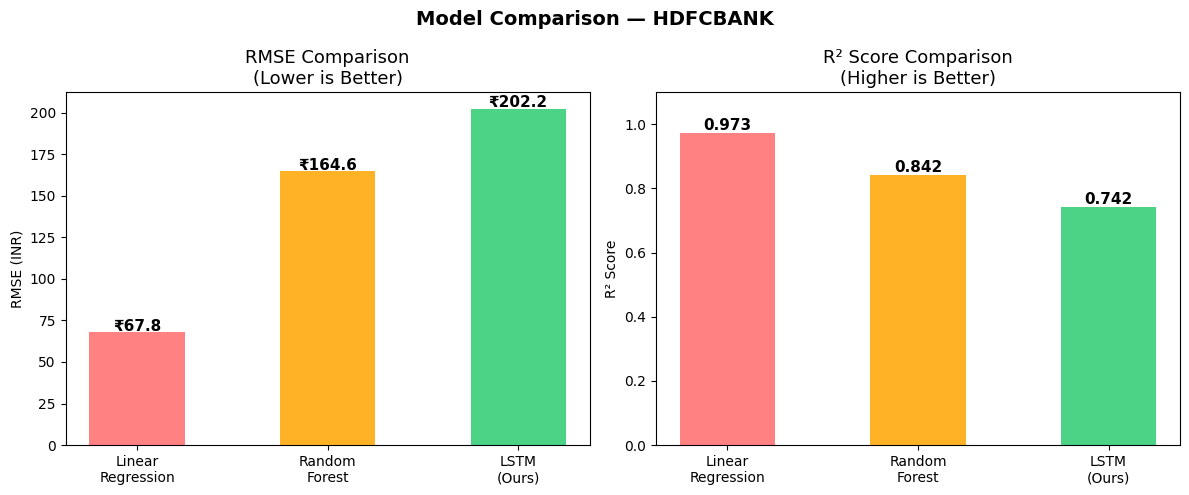

In [27]:
# Prepare baseline data
stock_base    = df[df['Symbol'] == SYMBOL].copy()
stock_base    = stock_base[stock_base['Date'] >= '2012-01-01']
base_features = ['MA_20', 'MA_50', 'RSI', 'MACD',
                 'Volatility_20', 'Momentum_20', 'Volume_Ratio']
stock_base    = stock_base.dropna().reset_index(drop=True)

X_base  = stock_base[base_features].values
y_base  = stock_base['Close'].values
split_b = int(len(X_base) * 0.80)

X_tr_b  = X_base[:split_b];  X_te_b = X_base[split_b:]
y_tr_b  = y_base[:split_b];  y_te_b = y_base[split_b:]

# Linear Regression
lr = LinearRegression()
lr.fit(X_tr_b, y_tr_b)
lr_pred = lr.predict(X_te_b)
lr_rmse = np.sqrt(mean_squared_error(y_te_b, lr_pred))
lr_r2   = r2_score(y_te_b, lr_pred)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tr_b, y_tr_b)
rf_pred = rf.predict(X_te_b)
rf_rmse = np.sqrt(mean_squared_error(y_te_b, rf_pred))
rf_r2   = r2_score(y_te_b, rf_pred)

# Print table
print("=" * 55)
print(f"      MODEL COMPARISON — {SYMBOL}")
print("=" * 55)
print(f"  {'Model':<25} {'RMSE':>10} {'R² Score':>12}")
print("-" * 55)
print(f"  {'Linear Regression':<25} {lr_rmse:>10.2f} {lr_r2:>12.4f}")
print(f"  {'Random Forest':<25} {rf_rmse:>10.2f} {rf_r2:>12.4f}")
print(f"  {'LSTM (Our Model)':<25} {rmse:>10.2f} {r2:>12.4f}")
print("=" * 55)

# Chart
models = ['Linear\nRegression', 'Random\nForest', 'LSTM\n(Ours)']
rmses  = [lr_rmse, rf_rmse, rmse]
r2s    = [lr_r2,   rf_r2,   r2]
colors = ['#FF6B6B', '#FFA500', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(models, rmses, color=colors,
                    alpha=0.85, width=0.5)
axes[0].set_title('RMSE Comparison\n(Lower is Better)', fontsize=13)
axes[0].set_ylabel('RMSE (INR)')
for bar, val in zip(bars1, rmses):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'₹{val:.1f}', ha='center',
        fontsize=11, fontweight='bold')

bars2 = axes[1].bar(models, r2s, color=colors,
                    alpha=0.85, width=0.5)
axes[1].set_title('R² Score Comparison\n(Higher is Better)', fontsize=13)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars2, r2s):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}', ha='center',
        fontsize=11, fontweight='bold')

plt.suptitle(f'Model Comparison — {SYMBOL}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

In [28]:
model.save('../models/lstm_hdfcbank.keras')
print(" Model saved!")

pd.DataFrame({
    'Actual':    y_test_actual,
    'Predicted': y_pred_actual
}).to_csv('../data/processed/hdfcbank_predictions.csv', index=False)
print(" Predictions saved!")
print("\n Stock Predictor Module Complete!")

 Model saved!
 Predictions saved!

 Stock Predictor Module Complete!
